## ДЗ №1. Метрики и простейшие алгоритмы рекомендаций

## Общая информация
**Дата выдачи: 24 января 2025**

**Дедлайн: 8 февраля 2025 23:59 MSK**

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from typing import List, Optional
from metric_tests import run_tests

%matplotlib inline

## О задании

В этой работе мы посмотрим на то, как работают самые простые модели для рекомендаций. Как правило, они не требуют построения специальных моделей, но даже так оказываются полезны в качестве бейзлайна. Попробуем сделать предсказания с помощью EASE. Это тоже довольно простой подход, но не стоит забывать, что сложные модели могут оказаться не лучшим выбором в условиях большого количества данных. Посчитаем метрики, построим графики и подумаем, насколько хорошо эти модели вообще решают поставленную задачу.

Мы будем работать с датасетом по рекомендации фильмов от Kion MTS, который был дан для соревнования. Сперва нужно его предобработать, эта часть повторяет то, что было на семинаре. 

Датасет необходимо скачать: https://ods.ai/competitions/competition-recsys-21/data

Оттуда нужны файлы `interactions.csv` и `items.csv`

Каждое задание весит **1 балл**, если выполнено полностью и без ошибок, **0 баллов** ставится при наличии хотя бы 1 ошибки. Максимальная оценка - **10 баллов**. Шаблоны функций и классов можно менять по своему усмотрению.

In [2]:
df = pd.read_csv('interactions.csv').iloc[:-1]
df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [3]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
2018771,808515,12228,118,432,4.0
992905,713381,111,148,6906,100.0
1558139,6518,7408,158,81,1.0
2264187,758014,1418,102,461,9.0
3211614,965613,7392,78,2013,28.0


Сделаем разбиение по времени

<Axes: >

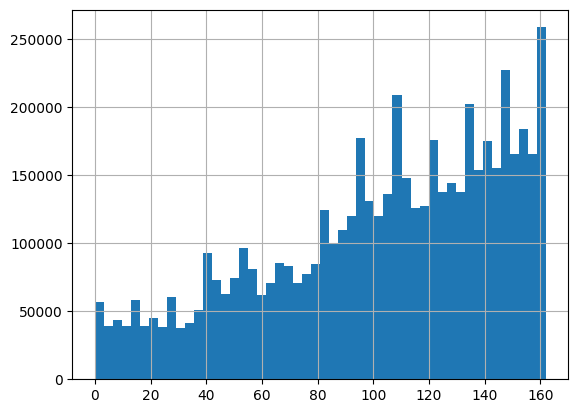

In [4]:
df.last_watch_dt.hist(bins=50)

In [5]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [6]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

И переведём всё к соединённому датасету:

In [7]:
n_users = 10000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users

In [8]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
11,988709,7571,116,6558,100.0
73,820464,3071,35,4708,80.0
145,141072,7308,119,8657,100.0
247,284039,9728,122,604,9.0
284,37298,7107,56,147,25.0


In [9]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

/var/folders/4g/7w3zz2lj1d5bwq_jd175wjtw0000gn/T/ipykernel_26280/1105526701.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_grouped = train_df.groupby('user_id').apply(
/var/folders/4g/7w3zz2lj1d5bwq_jd175wjtw0000gn/T/ipykernel_26280/1105526701.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_grouped = test_df.groupby('user_id').apply(


,user_id,train_interactions
0,47,"[(13361, 138), (13865, 138), (7401, 142), (129..."
1,181,"[(12192, 145), (10440, 145), (13018, 146), (41..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ..."
3,446,"[(13865, 105)]"
4,495,"[(1136, 6)]"


In [10]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,47,"[(13361, 138), (13865, 138), (7401, 142), (129...","[(14488, 160)]"
1,181,"[(12192, 145), (10440, 145), (13018, 146), (41...","[(16228, 159), (4880, 160)]"
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633..."
3,446,"[(13865, 105)]","[(12202, 160), (230, 160)]"
4,495,"[(1136, 6)]","[(16244, 153), (5434, 153), (4946, 155), (1236..."


In [11]:
np.random.seed(777)

class Random:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        items = set()
        for _, row in df.iterrows():
            for item, _ in row[col]:
                items.add(item)

        self.items = list(items)
        self.trained = True

    def predict(self, df, topn=10):
        assert self.trained
        return [np.random.choice(self.items, replace=False, size=topn)]*len(df)


random = Random()
random.fit(joined)

joined['random_recs'] = random.predict(joined, topn=3)
joined.head()

,user_id,train_interactions,test_interactions,random_recs
0,47,"[(13361, 138), (13865, 138), (7401, 142), (129...","[(14488, 160)]","[15805, 382, 10351]"
1,181,"[(12192, 145), (10440, 145), (13018, 146), (41...","[(16228, 159), (4880, 160)]","[15805, 382, 10351]"
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[15805, 382, 10351]"
3,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[15805, 382, 10351]"
4,495,"[(1136, 6)]","[(16244, 153), (5434, 153), (4946, 155), (1236...","[15805, 382, 10351]"


**Задание №1. Метрики и бейзлайны**

Добавьте реализацию метрик AP, RR, HR, их усреднённые версии по $U$ мы посчитаем ниже. За имплементацию с циклами балл будет снижаться, векторизуйте! ( ͡° ͜ʖ ͡°)

$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$
p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)
$$
$$
RR@k = \dfrac{1}{\text{rank}_i@k}
$$
$$
HR@k = [\exists \ y_i = 1 \ \text{among k preds}]
$$


*   $n_u$ - число айтемов, с которыми взаимодействовал юзер $u$
*   $y_i$ - релевантно ли $i$-ое предсказание, $y_i \in \{0,1\}$
* $\text{rank}_i@k$ - позиция первого релеваннтого айтема среди первых $k$ предсказаний
* HR@k - среди первых $k$ предсказаний есть хотя бы одно релевантное

Считайте, что если `topn` не задано, то берётся всегда $n_u$. 

In [69]:
def ap_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):      
    if topn is None:
        predictions_k = predictions
        denominator = len(gt_items)
    else:
        predictions_k = predictions[:topn]
        denominator = min(topn, len(gt_items))
        
    relevance = np.isin(predictions_k, gt_items).astype(float)
    
    positions = np.arange(1, len(predictions_k) + 1)
    precision_i = np.cumsum(relevance) / positions
    
    return float(np.sum(relevance * precision_i) / denominator)

def rr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):   
    if topn is None:
        predictions_k = predictions
    else:
        predictions_k = predictions[:topn]
    
    if (np.isin(predictions_k, gt_items).any()):
        rank_k = np.isin(predictions_k, gt_items).argmax() + 1
        return 1.0 / rank_k
    else:
        return 0.0

def hr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):
    if topn is None:
        predictions_k = predictions
    else:
        predictions_k = predictions[:topn]
    
    return float(np.isin(predictions_k, gt_items).any())

Для вашего удобства в файле `metric_tests.py` есть тесты, но хардкодить их, разумеется, не стоит. 

In [70]:
run_tests(ap_metric, rr_metric, hr_metric)

В следующей ячейке код, который считает и усредняет метрики по юзерам. Он взят с семинара, при желании можно его тоже модифицировать, например, векторизовать. 

In [71]:
def evaluate_recommender(df, model_preds, gt_col='test_interactions'):

    metric_values = []

    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        predictions = row[model_preds]

        ap = ap_metric(gt_items, predictions)
        rr = rr_metric(gt_items, predictions)
        hr = hr_metric(gt_items, predictions)

        metric_values.append((ap, rr, hr))

    return {'map': np.mean([x[0] for x in metric_values]),
            'mrr': np.mean([x[1] for x in metric_values]),
            'hr': np.mean([x[2] for x in metric_values])}

Если вы всё сделали правильно, рандомные предсказания должны дать хоть какое-то качество, но не очень большое.

In [73]:
evaluate_recommender(joined, model_preds='random_recs')

{'map': np.float64(6.83080808080808e-05),
 'mrr': np.float64(0.0002333333333333333),
 'hr': np.float64(0.0006)}

In [76]:
class TopPopular:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1

        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

        self.recommendations = [x[0] for x in counts]
        self.trained = True

    def predict(self, df, topn=10)  -> List[np.ndarray]:

        assert self.trained
        return [self.recommendations[:topn]]*len(df)


toppop = TopPopular()
toppop.fit(joined)

joined['toppopular_recs'] = toppop.predict(joined)
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs
0,47,"[(13361, 138), (13865, 138), (7401, 142), (129...","[(14488, 160)]","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
1,181,"[(12192, 145), (10440, 145), (13018, 146), (41...","[(16228, 159), (4880, 160)]","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
3,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
4,495,"[(1136, 6)]","[(16244, 153), (5434, 153), (4946, 155), (1236...","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."


Самые популярные предсказания должны показать более высокое качество.

In [77]:
evaluate_recommender(joined, model_preds='toppopular_recs')

{'map': np.float64(0.06296051977827227),
 'mrr': np.float64(0.11528654761904764),
 'hr': np.float64(0.2708)}

**Задание №2. Рекомендации в окне**

Здесь необходимо переделать метод рекомендации по популярности так, что популярность считается только за какое-то более свежее временное окно. Под окном подразумевается какой-то временной промежуток, например, ближайший месяц. Соответственно, всё что за его пределами, не учитывается.

In [78]:
class TopPopularWeighted(TopPopular):

    def __init__(self, min_window=2):
        super().__init__()
        self.min_window = min_window
        
    def fit(self, df, col='train_interactions'):
        counts = {}
        
        max_time = None
        for _, row in df.iterrows():
            for item, timestamp in row[col]:
                if max_time is None or timestamp > max_time:
                    max_time = timestamp
        
        time_threshold = max_time - self.min_window
        
        for _, row in df.iterrows():
            for item, timestamp in row[col]:
                if timestamp >= time_threshold:
                    if item in counts:
                        counts[item] += 1
                    else:
                        counts[item] = 1
        
        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
        
        self.recommendations = [x[0] for x in counts]
        self.trained = True

Теперь постройте графики зависимости значений трёх метрик (AP@k, RR@k, HR@k) от размера окна. 

In [100]:
windows = np.arange(1, 31)
results = {'window': [], 'metrics': []}

for window in windows:
    toppopweight = TopPopularWeighted(min_window = window)
    toppopweight.fit(joined)

    joined['toppopularweighted_recs'] = toppopweight.predict(joined)
    
    results['window'].append(window)
    results['metrics'].append(evaluate_recommender(joined, model_preds='toppopularweighted_recs'))

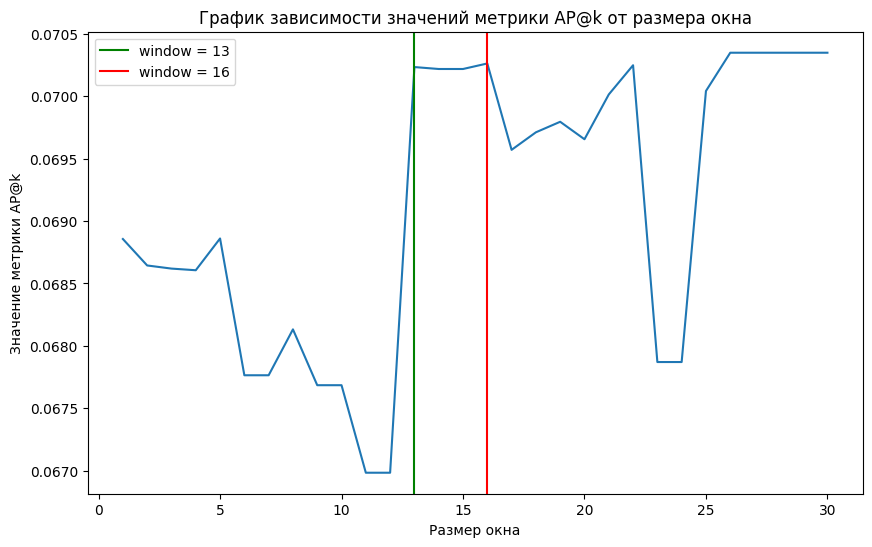

In [131]:
plt.figure(figsize = (10, 6))
plt.plot(results['window'], [x['map'] for x in results['metrics']])
plt.axvline(13, color = 'g', label = 'window = 13')
plt.axvline(16, color = 'r', label = 'window = 16')
plt.xlabel('Размер окна')
plt.ylabel('Значение метрики AP@k')
plt.title('График зависимости значений метрики AP@k от размера окна')
plt.legend()
plt.show()

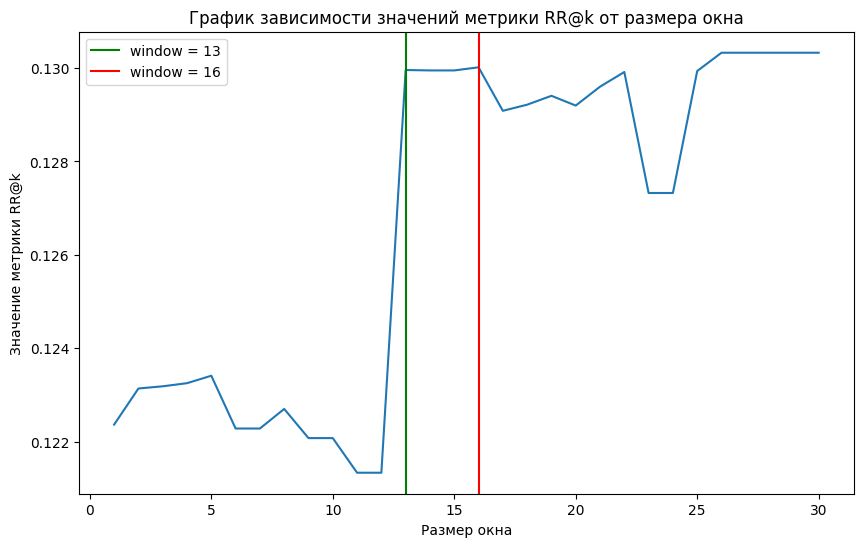

In [132]:
plt.figure(figsize = (10, 6))
plt.plot(results['window'], [x['mrr'] for x in results['metrics']])
plt.axvline(13, color = 'g', label = 'window = 13')
plt.axvline(16, color = 'r', label = 'window = 16')
plt.xlabel('Размер окна')
plt.ylabel('Значение метрики RR@k')
plt.title('График зависимости значений метрики RR@k от размера окна')
plt.legend()
plt.show()

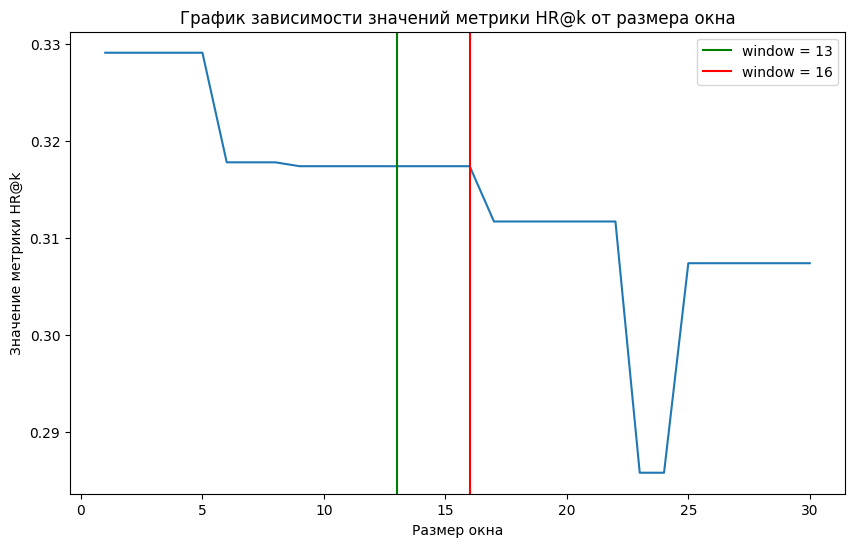

In [133]:
plt.figure(figsize = (10, 6))
plt.plot(results['window'], [x['hr'] for x in results['metrics']])
plt.axvline(13, color = 'g', label = 'window = 13')
plt.axvline(16, color = 'r', label = 'window = 16')
plt.xlabel('Размер окна')
plt.ylabel('Значение метрики HR@k')
plt.title('График зависимости значений метрики HR@k от размера окна')
plt.legend()
plt.show()

Подумайте и ответьте, как размер окна влияет на качество рекомендаций. Какое значение наилучшее, есть ли у этого разумное объяснение?

**Ответ:** С увеличением размера окна метрики AP@k и RR@k сначала немного падают, а потом растут и стабилизируются, метрика HR@k же, можно считать, всё время падает. Мне кажется, что оптимальным значением окна будет от 13 до 16 (между зелёной и красной линиями на графиках), так как эти значения сохраняют баланс метрик. 16 всё-таки немного получше и можно отметить его как наилучшее значение. Уменьшение HR@k, вероятно, связано с тем, что при маленьких окнах мы хорошо ловим новинки и актуальные тренды, а большое окно лучше улавливает долгосрочные предпочтения, что вызывает рост AP@k и RR@k.

**Задание №3. Метрики и k.**

Постройте зависимость значений MAP@K, MRR@K, HR@K для метода рекомендации по популярности. Возьмите какие-нибудь k, например, от 1 до 100, переберите значения и покажите на линейном графике.

In [134]:
k_list = np.arange(1, 101)
results = {'k': [], 'metrics': []}

for k in k_list:
    joined['toppopular_recs'] = toppop.predict(joined, topn = k)
    
    results['k'].append(k)
    results['metrics'].append(evaluate_recommender(joined, model_preds = 'toppopular_recs'))

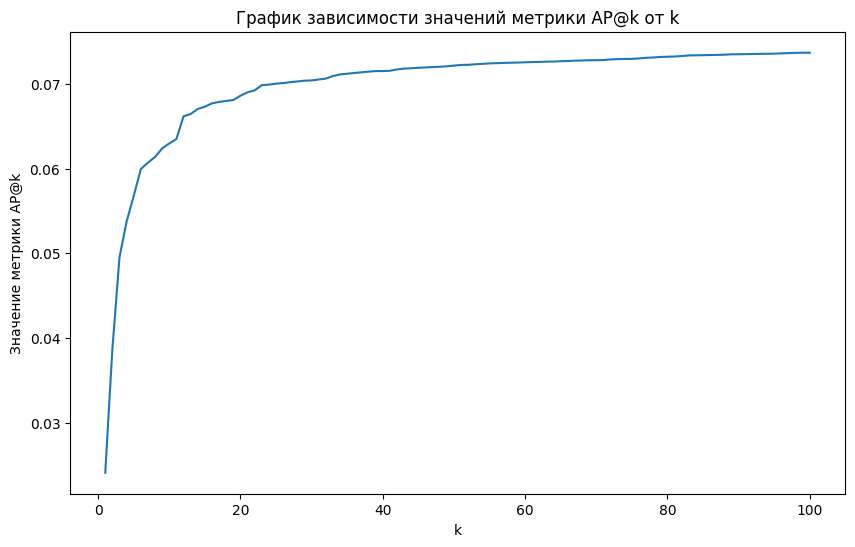

In [136]:
plt.figure(figsize = (10, 6))
plt.plot(results['k'], [x['map'] for x in results['metrics']])
plt.xlabel('k')
plt.ylabel('Значение метрики AP@k')
plt.title('График зависимости значений метрики AP@k от k')
plt.show()

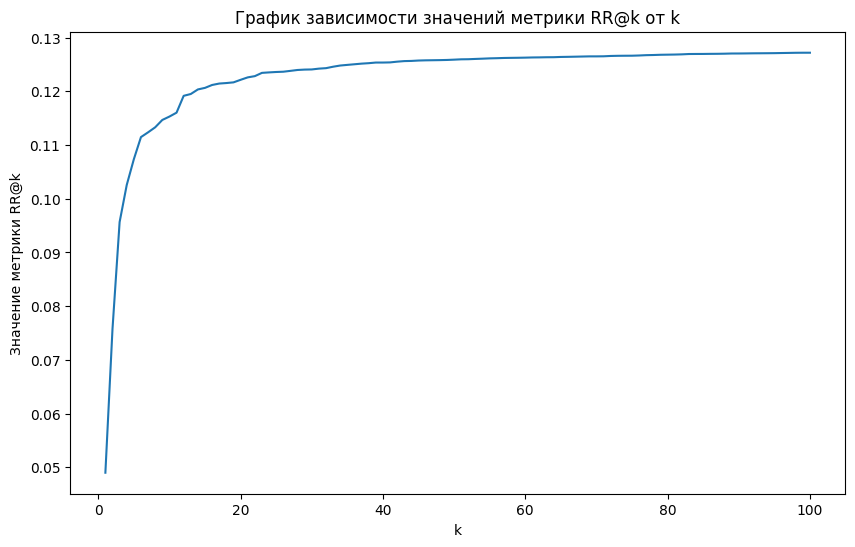

In [139]:
plt.figure(figsize = (10, 6))
plt.plot(results['k'], [x['mrr'] for x in results['metrics']])
plt.xlabel('k')
plt.ylabel('Значение метрики RR@k')
plt.title('График зависимости значений метрики RR@k от k')
plt.show()

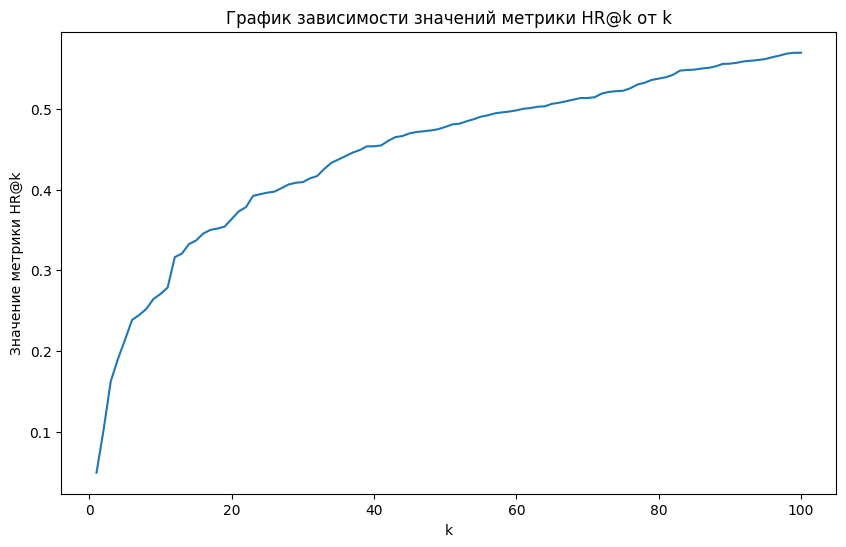

In [140]:
plt.figure(figsize = (10, 6))
plt.plot(results['k'], [x['hr'] for x in results['metrics']])
plt.xlabel('k')
plt.ylabel('Значение метрики HR@k')
plt.title('График зависимости значений метрики HR@k от k')
plt.show()

Хорошенько подумайте и ответьте на вопросы ниже.

3.1 Какие из метрик являются монотонными функциями по top-K? Объясните, почему они являются монотонными? \
**Ответ:** MAP@k немонотонна, так как в теории при добавлении нерелевантного элемента оно может уменьшиться. MRR@k монотонна, так как при увеличении k мы можем только найти для какого-то юзера релевантный айтем, который ещё его не нашёл вообще. HR@k монотонна, так как релевантный объект может только появится у какого-то юзера, а если уже есть, то ничего не изменится.

3.2 Объясните по каждой метрике, как можно интерпретировать ее график? То есть, что можно сказать про связь изменения метрики c возможными пользовательскими сценариями, например,скроллингом ленты новостей. \
**Ответ:** У метрики MAP@k быстрый старт, что говорит о релевантности первых айтемов при скроллинге ленты, а далее почти все релевантные айтемы уже найдены и метрика стабилизируется. У метрики MRR@k тоже идёт быстрый старт, так как сначала идут попурляные айтемы и у юзера при скроллинге ленты высокая вероятность сразу найти что-то релевантное, а затем почти все юзеры уже нашли что-то релевантное и график стабилизируется. Метрика HR@k также быстро растёт вначале, но продолжает расти более равномерно на всём промежутке, вероятно, есть группа юзеров, для которых модель промахивается.

3.3 Как вы думаете, почему графики выглядят именно так? Должны ли они возрастать/убывать, от чего это может зависеть? (Тут вам может помочь дополнительный анализ данных)\
**Ответ:** Могу предположить, что модель хорошо улавливает основные тренды и если понимает юзера, то понимает чётко, но есть трудные юзеры, которым тяжело угодить.

**Задание №4. Интерпретация рейтингов**

Возьмите названия фильмов/сериалов из `items.csv`, выделите 5 различных сценариев изменения популярности у фильмов, аргументируйте (например, графиком или статистикой) и проинтерпретируейте их (почему популярность для этого фильма меняется так). Обратите внимание, что надо найти именно разные паттерны изменения вероятностей. 

In [141]:
items = pd.read_csv('items.csv')[['item_id','title']].copy()
items.head()

,item_id,title
0,10711,Поговори с ней
1,2508,Голые перцы
2,10716,Тактическая сила
3,7868,45 лет
4,16268,Все решает мгновение


Пример:

1917


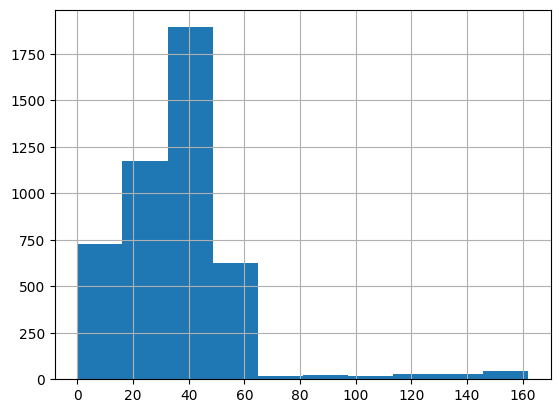

In [150]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

# это для примера, хотя выцеплять случаи по одному может быть не лучшей идеей
sampled_id = 3402

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist();

Фильм 1917 какое-то время набирал популярность, потом видим резкое падение (кстати, с какой даты?). Возможно, это связано с ограничением доступности этого фильма для части пользователей, периодом проката фильма / рекламной кампании или другой причиной. 

Добавьте 5 своих примеров ниже. Опишите, как вы их искали. 

Планета обезьян


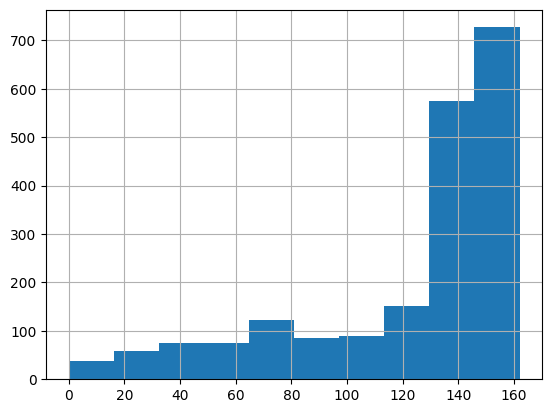

In [382]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

sampled_id = 111

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist();

Фильм "Планета обезьян" стабильно держался на одном уровне и очень резко набрал популярность к концу промежутка.

7,3 тонны


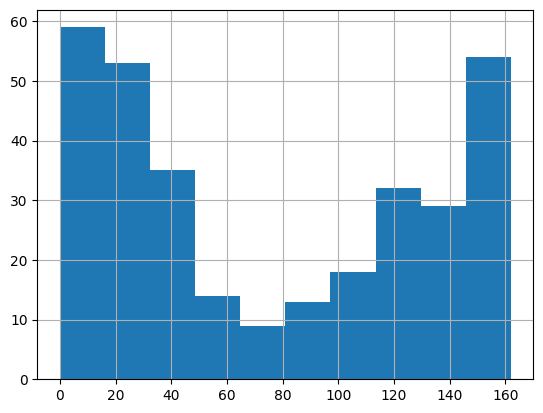

In [383]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

sampled_id = 86

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist();

Фильм "7,3 тонны" какое-то время был популярен, затем плавно утратил её и снова набрал, возможно, выходил из проката.

Жестокий Стамбул


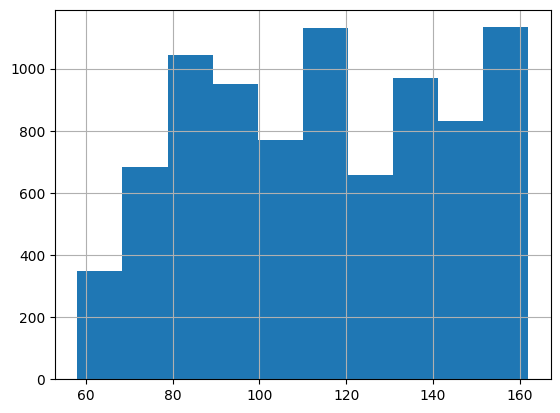

In [384]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

sampled_id = 14

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist();

После выпуска сериал "Жестокий Стамбул" обрёл популярность и удерживает её до сих пор примерно на одном уровне.

Эспен в королевстве троллей


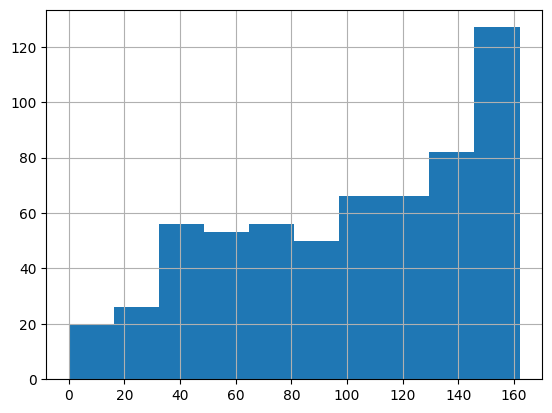

In [385]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

sampled_id = 35

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist();

Фильм "Эспен в королевстве троллей" растёт в популярности на протяжении всего промежутка.

Стелс


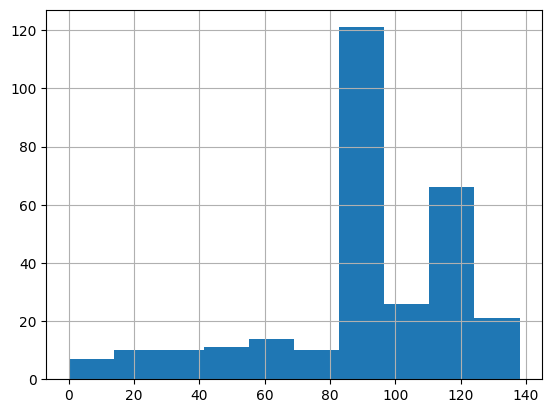

In [386]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

sampled_id = 78

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist();

На всём промежутке фильм "Стелс" был непопулярен, но в какой-то короткий период обрёл популярность, вероятно, в связи с какими-то событиями в реальности и затем снова вернулся к своему обычному состоянию.

Все примеры искал вручную.

**Задание №5. User-item encoding**

Теперь, создайте матрицу интеракций user-item по примеру из семинара. Вам нужно в итоге получить разреженную матрицу (sparse matrix), в которой в качестве строк будут пользователи, в качестве колонок - айтемы. Не забудьте перекодировать пользователей и айтемы через энкодер. В отличие от семинара, оставьте в матрице только юзеров и айтемы, которые встречались в матрице > 4 раз.

Важно: когда вы отфильтруете юзеров на встречаемость > 4 раз, вы удалите какие-то айтемы, которые теперь станут встречаться меньше 5 раз. Поэтому у вас перестанет выполняться второе условие на минимальное число интеракций с айтемом. Тогда вам надо опять отфильтровать айтемы на встречаемость, но это снова может нарушить условие для юзеров. В таком случае, вам надо написать итеративный алгоритм до сходимости, пока требования не будут выполняться в обеих колонках. 

In [255]:
def filter_columns(df, min_freq):
    """
    Filter dataframe, excluding least active users and least popular items.
    Return a copy of the dataframe with at least min_freq entries
    in both users and items
    """
    df_filtered = df.copy()
    
    user_counts = df_filtered['user_id'].value_counts()
    valid_users = user_counts[user_counts >= min_freq].index
    df_filtered = df_filtered[df_filtered['user_id'].isin(valid_users)]
    
    item_counts = df_filtered['item_id'].value_counts()
    valid_items = item_counts[item_counts >= min_freq].index
    df_filtered = df_filtered[df_filtered['item_id'].isin(valid_items)]
    
    return df_filtered

def filter_dataframe(df, min_freq = 5):
    """
    Filter dataframe by given columns until each of them satisfies
    min_freq condition, guaranteed by filter_columns. Return a copy
    of the dataframe
    """
    df_filtered = df.copy()
    last_len = 0
    
    while len(df_filtered) != last_len:
        last_len = len(df_filtered)
        df_filtered = filter_columns(df_filtered, min_freq)
    
    return df_filtered

filtered_train = filter_dataframe(train_df, min_freq = 5)

In [256]:
def df_encode(df):
    item2id = {k:v for v, k in enumerate(df.item_id.unique())}
    user2id = {k:v for v, k in enumerate(df.user_id.unique())}

    id2item = {k:v for v, k in item2id.items()}
    id2user = {k:v for v, k in user2id.items()}

    df['user_id'] = df.user_id.apply(lambda x: user2id[x])
    df['item_id'] = df.item_id.apply(lambda x: item2id[x])
    
    return df, user2id, item2id, id2user, id2item

filtered_train, user2id, item2id, id2user, id2item = df_encode(filtered_train)
filtered_train.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
3334344,2845,259,46,5796,100.0
1513912,4011,1005,128,6664,100.0
3476748,2026,524,138,536,8.0
4345365,4161,282,109,1,0.0
4402903,4407,430,10,297,3.0


In [257]:
from scipy import sparse as sps

matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape = (len(user2id), len(item2id)),
)
matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 107702 stored elements and shape (5949, 3049)>

**Задание №6. Интеракции и частота**

Постройте график зависимости количества айтемов и юзеров от значений (порогов) фильтров на встречаемость в матрице интеракций. То есть, нужно выполнить задание №5 для нескольких значений `min_freq` и построить график зависимости числа оставшихся айтемов и юзеров от этого параметра.

In [247]:
min_freq_list = np.arange(2, 11)
count_items = []
count_users = []

for min_freq in min_freq_list:
    filtered_train = filter_dataframe(train_df, min_freq = min_freq)
    filtered_train, user2id, item2id, id2user, id2item = df_encode(filtered_train)
    
    count_items.append(len(item2id))
    count_users.append(len(user2id))

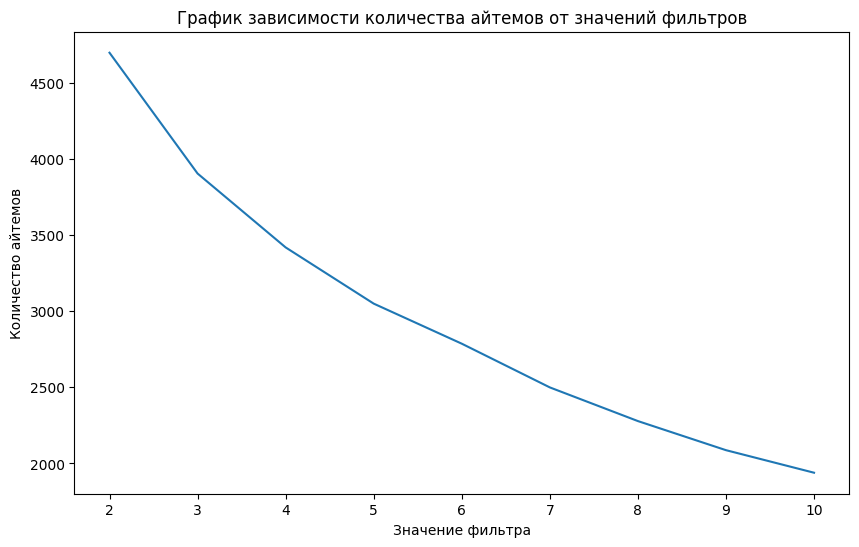

In [249]:
plt.figure(figsize = (10, 6))
plt.plot(min_freq_list, count_items)
plt.xlabel('Значение фильтра')
plt.ylabel('Количество айтемов')
plt.title('График зависимости количества айтемов от значений фильтров')
plt.show()

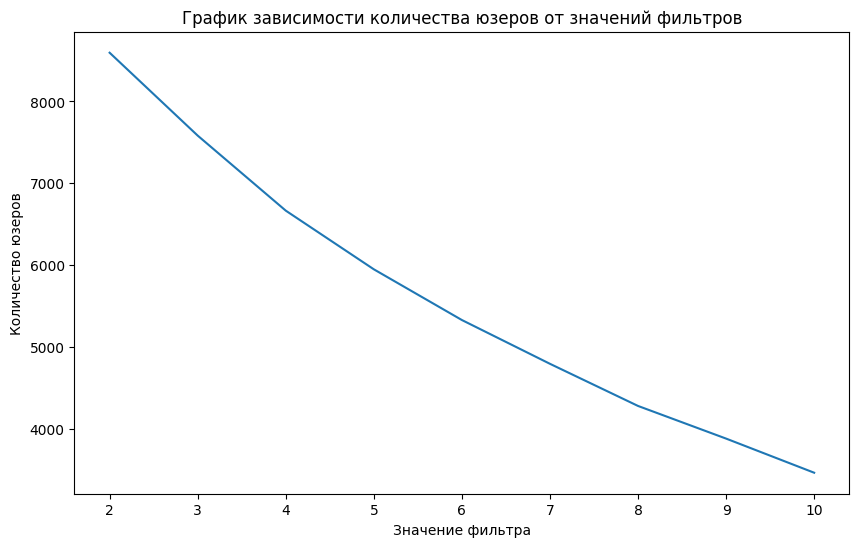

In [251]:
plt.figure(figsize = (10, 6))
plt.plot(min_freq_list, count_users)
plt.xlabel('Значение фильтра')
plt.ylabel('Количество юзеров')
plt.title('График зависимости количества юзеров от значений фильтров')
plt.show()

**Задание №7. EASE**

Реализуйте EASE, постройте рекомендации для юзеров. Сравните все имплементированные ранее метрики качества с `TopPopular` для некоторого набора k. 

Реализацию можно взять из семинара. Можно реализовать по статье https://arxiv.org/pdf/1905.03375.pdf. Можно взять и адаптировать из RecBole https://github.com/RUCAIBox/RecBole.

In [258]:
%%time

# Обучаем конечную модель
# Мы взяли реализацию из RecBole
#
def fit_ease(X, reg_weight = 1000):

    # gram matrix
    G = X.T @ X

    # add reg to diagonal
    G += reg_weight * sps.identity(G.shape[0])

    # convert to dense because inverse will be dense
    G = G.todense()

    # invert. this takes most of the time
    P = np.linalg.inv(G)
    B = P / (-np.diag(P))
    
    # zero out diag
    np.fill_diagonal(B, 0.)

    return B

w = fit_ease(matrix)

CPU times: user 3.63 s, sys: 108 ms, total: 3.74 s
Wall time: 589 ms


Далее, вам надо реализовать функцию получения предсказаний. У вас есть обученная матрица весов, которую можно использовать для получения предсказаний. Для этого нужно построить вектор интеракций пользователя и умножить его на матрицу весов.

In [259]:
def get_preds(x, item2id, id2item, w, topk = 100):
    user_items = [item for item, _ in x]

    encoded = [item2id[t] for t in user_items if t in item2id]

    vector = np.zeros(len(item2id), dtype=np.float32)
    vector[encoded] = 1.0
    vector = sps.csr_matrix(vector)
    
    preds = np.asarray(vector.dot(w)).ravel()
    #preds[encoded] = -np.inf

    ranks = np.argsort(-preds)[:topk]

    return [id2item[i] for i in ranks]

joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item, w))
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs,toppopularweighted_recs,ease_preds
0,47,"[(13361, 138), (13865, 138), (7401, 142), (129...","[(14488, 160)]","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[9728, 10440, 15297, 3734, 13865, 4151, 7829, ...","[10440, 9728, 3734, 12995, 8636, 15297, 6774, ..."
1,181,"[(12192, 145), (10440, 145), (13018, 146), (41...","[(16228, 159), (4880, 160)]","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[9728, 10440, 15297, 3734, 13865, 4151, 7829, ...","[15297, 4880, 10440, 3734, 13865, 142, 9728, 4..."
2,322,"[(4549, 94), (8419, 94), (14814, 94), (10219, ...","[(4651, 155), (15384, 155), (11099, 157), (633...","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[9728, 10440, 15297, 3734, 13865, 4151, 7829, ...","[10440, 13865, 9728, 3734, 15297, 4151, 142, 2..."
3,446,"[(13865, 105)]","[(12202, 160), (230, 160)]","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[9728, 10440, 15297, 3734, 13865, 4151, 7829, ...","[9728, 10440, 3734, 15297, 12995, 8636, 4495, ..."
4,495,"[(1136, 6)]","[(16244, 153), (5434, 153), (4946, 155), (1236...","[15805, 382, 10351]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[9728, 10440, 15297, 3734, 13865, 4151, 7829, ...","[8636, 1844, 9996, 5508, 7662, 14317, 4533, 56..."


In [268]:
k_list = np.arange(1, 101)
results = {'k': [], 'metrics_toppop': [], 'metrics_ease': []}

for k in k_list:
    joined['toppopular_recs'] = toppop.predict(joined, topn = k)
    joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item, w, topk = k))
    
    results['k'].append(k)
    results['metrics_toppop'].append(evaluate_recommender(joined, model_preds = 'toppopular_recs'))
    results['metrics_ease'].append(evaluate_recommender(joined, model_preds = 'ease_preds'))

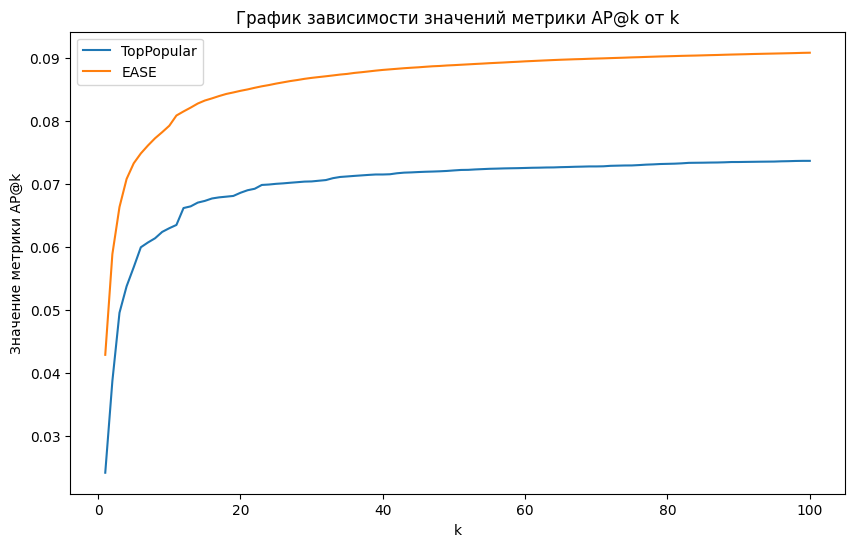

In [269]:
plt.figure(figsize = (10, 6))
plt.plot(results['k'], [x['map'] for x in results['metrics_toppop']], label = 'TopPopular')
plt.plot(results['k'], [x['map'] for x in results['metrics_ease']], label = 'EASE')
plt.xlabel('k')
plt.ylabel('Значение метрики AP@k')
plt.title('График зависимости значений метрики AP@k от k')
plt.legend()
plt.show()

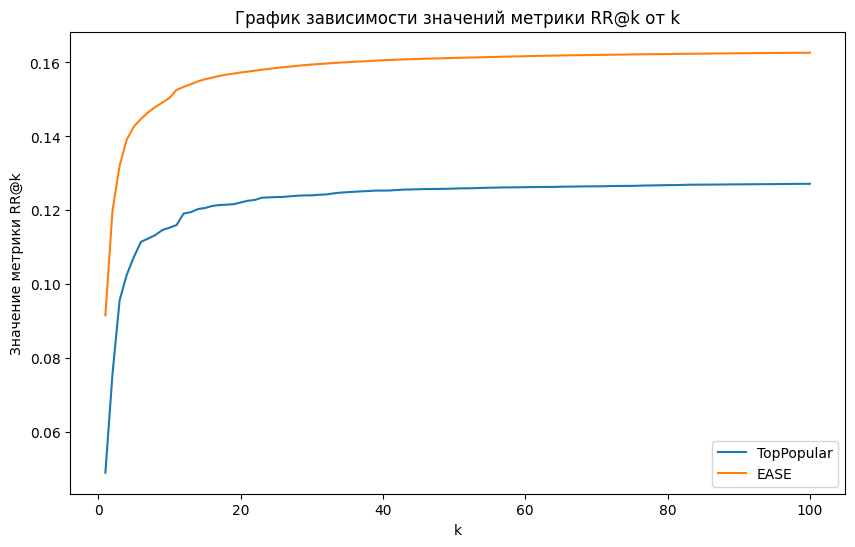

In [270]:
plt.figure(figsize = (10, 6))
plt.plot(results['k'], [x['mrr'] for x in results['metrics_toppop']], label = 'TopPopular')
plt.plot(results['k'], [x['mrr'] for x in results['metrics_ease']], label = 'EASE')
plt.xlabel('k')
plt.ylabel('Значение метрики RR@k')
plt.title('График зависимости значений метрики RR@k от k')
plt.legend()
plt.show()

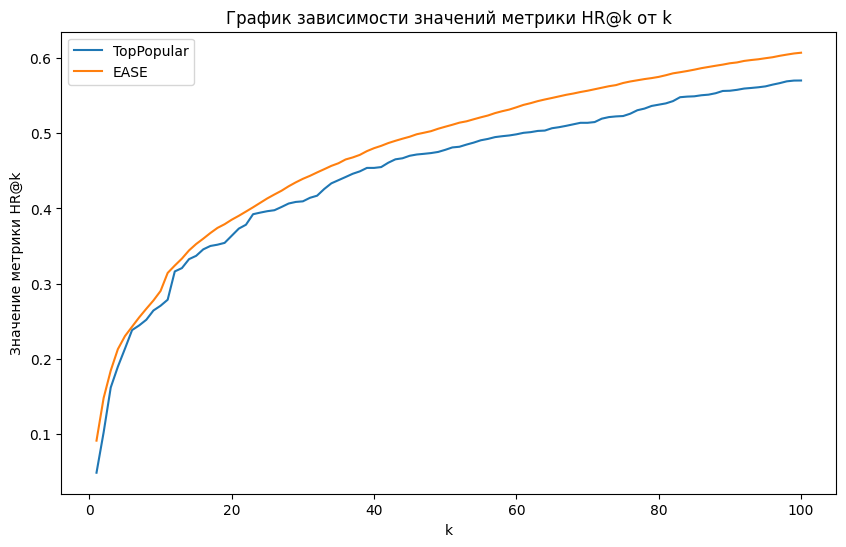

In [271]:
plt.figure(figsize = (10, 6))
plt.plot(results['k'], [x['hr'] for x in results['metrics_toppop']], label = 'TopPopular')
plt.plot(results['k'], [x['hr'] for x in results['metrics_ease']], label = 'EASE')
plt.xlabel('k')
plt.ylabel('Значение метрики HR@k')
plt.title('График зависимости значений метрики HR@k от k')
plt.legend()
plt.show()

Сделайте выводы — какой алгоритм работает лучше?

**Ответ:** EASE выглядит лучше, прилично выигрывая по AP@k c RR@k и немного по HR@k.

**Задание №8. Тюнинг**

Переберите различные значения гиперпараметра коэффициента регуляризации у EASE и постройте графики, как в задании №6. Постарайтесь "затюнить" EASE как можно лучше. Возьмите разумное число гиперпараметров - хотя бы штук 20 по логарифмической сетке, либо используйте более хитрые алгоритмы оптимизации. 

In [285]:
reg_weight_list = np.logspace(-2, 6, 20)
results = {'reg_weight': [], 'metrics': []}

for reg_weight in reg_weight_list:
    w = fit_ease(matrix, reg_weight = reg_weight)
    joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item, w))
    
    results['reg_weight'].append(reg_weight)
    results['metrics'].append(evaluate_recommender(joined, model_preds = 'ease_preds'))

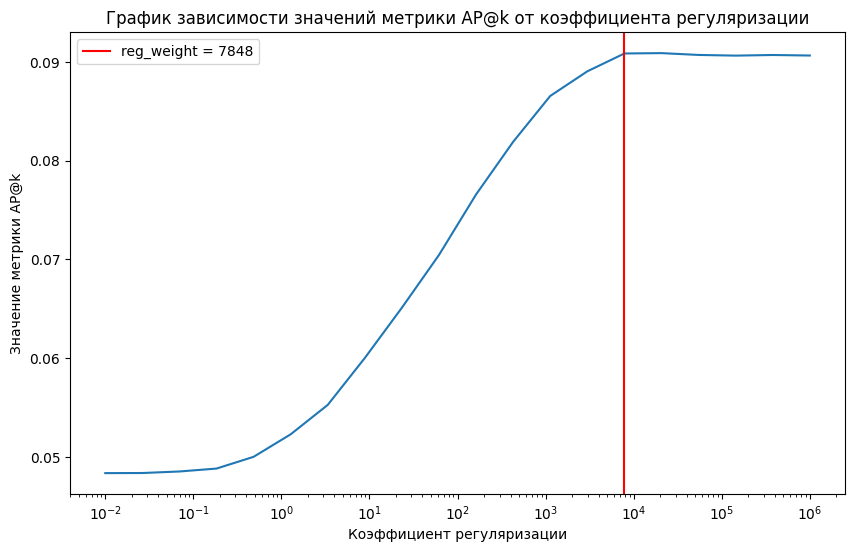

In [303]:
plt.figure(figsize = (10, 6))
plt.plot(results['reg_weight'], [x['map'] for x in results['metrics']])
plt.axvline(7848, color = 'r', label = 'reg_weight = 7848')
plt.xscale('log')
plt.xlabel('Коэффициент регуляризации')
plt.ylabel('Значение метрики AP@k')
plt.title('График зависимости значений метрики AP@k от коэффициента регуляризации')
plt.legend()
plt.show()

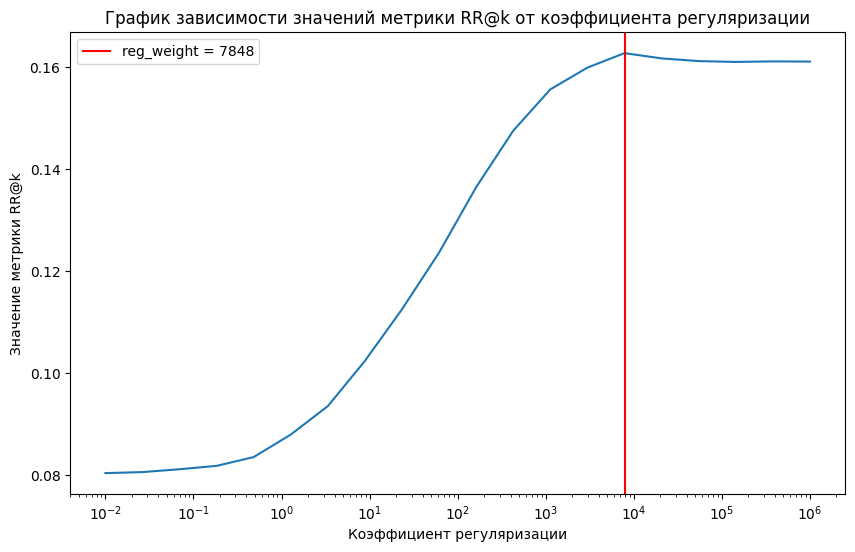

In [304]:
plt.figure(figsize = (10, 6))
plt.plot(results['reg_weight'], [x['mrr'] for x in results['metrics']])
plt.axvline(7848, color = 'r', label = 'reg_weight = 7848')
plt.xscale('log')
plt.xlabel('Коэффициент регуляризации')
plt.ylabel('Значение метрики RR@k')
plt.title('График зависимости значений метрики RR@k от коэффициента регуляризации')
plt.legend()
plt.show()

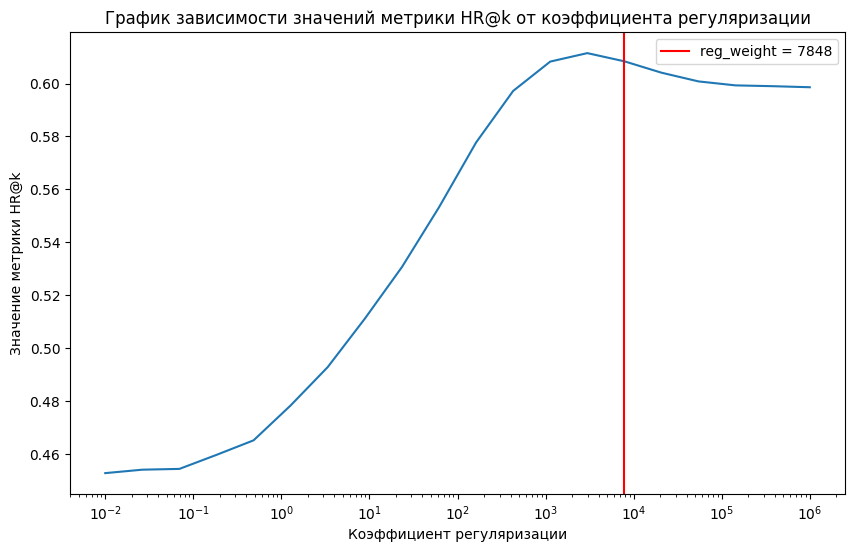

In [305]:
plt.figure(figsize = (10, 6))
plt.plot(results['reg_weight'], [x['hr'] for x in results['metrics']])
plt.axvline(7848, color = 'r', label = 'reg_weight = 7848')
plt.xscale('log')
plt.xlabel('Коэффициент регуляризации')
plt.ylabel('Значение метрики HR@k')
plt.title('График зависимости значений метрики HR@k от коэффициента регуляризации')
plt.legend()
plt.show()

Ответьте на следующие вопросы:

8.1 Какое значение гиперпараметра является наилучшим? 


**Ответ:** Думаю, что лучшим можно назвать reg_weight ≈ 7848 (красная линия на графиках), так как оно максимизирует 2 метрики из 3, немного теряя в оставшейся.

8.2 Что еще интересного вы можете сказать по графикам? Может быть, что-то свзяанное с распределением параметров, влиянием на отдельные метрики, скоростью тюнинга?

**Ответ:** Модель сначала быстро наращивает HR@k (пик в райноне 3000 на графике), то есть учится просто находить релевантные айтемы. Затем, когда HR@k достиг пика, модель учится лучше ранжировать, что происходит с ростом AP@k и RR@k до их пика (примерно 7848) и небольшим снижением HR@k. Далее уже избыточная регуляризация приводит к потере качества порядка.

**Задание №9. EASE и topk**

В лекции №2 говорилось, что качество у EASE растет с ослаблением фильтра на число айтемов. В этом задании постройте кривые метрик качества MAP/MRR/HR в зависимости от topk (например, от 1 до 100 с некоторым шагом), где кривая параметризована минимальным требуемым значением встречаемости user/item (из задания №6). Опишите свои выводы.

Важно: в этом задании линии могут быть мало различимыми, поэтому ваша задача для каждой метрики найти нужный масштаб на каких-то конкретных topk, чтобы линии стали визуально отличимы. 

In [322]:
min_freq_list = np.arange(2, 11)
results = {'min_freq': [], 'metrics_k50': [], 'metrics_k75': [], 'metrics_k100': []}

for min_freq in min_freq_list:
    filtered_train = filter_dataframe(train_df, min_freq = min_freq)
    filtered_train, user2id, item2id, id2user, id2item = df_encode(filtered_train)
    
    matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape = (len(user2id), len(item2id)),
    )
    
    w = fit_ease(matrix)
    results['min_freq'].append(min_freq)
    
    k_list =  [50, 75, 100]
    for k in k_list:
        joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, id2item, w, topk = k))
        results[f'metrics_k{k}'].append(evaluate_recommender(joined, model_preds = 'ease_preds'))

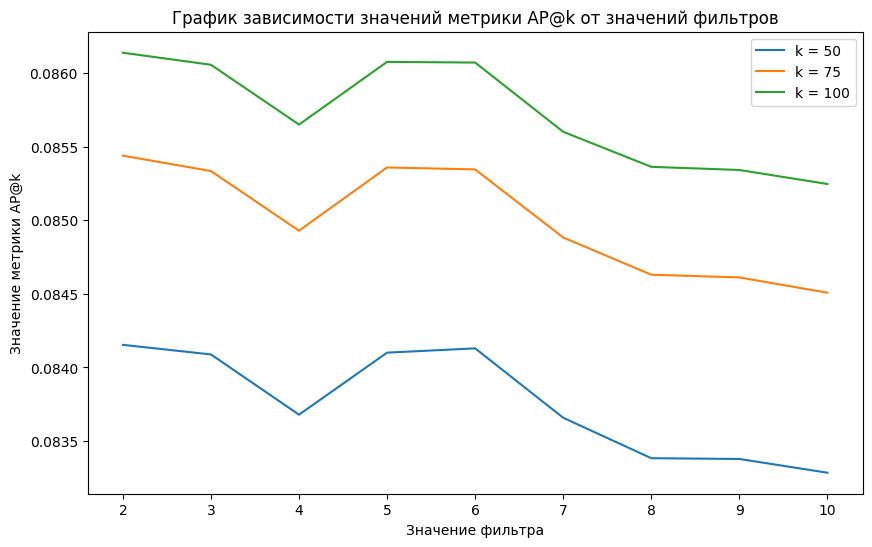

In [323]:
plt.figure(figsize = (10, 6))
plt.plot(results['min_freq'], [x['map'] for x in results['metrics_k50']], label = 'k = 50')
plt.plot(results['min_freq'], [x['map'] for x in results['metrics_k75']], label = 'k = 75')
plt.plot(results['min_freq'], [x['map'] for x in results['metrics_k100']], label = 'k = 100')
plt.xlabel('Значение фильтра')
plt.ylabel('Значение метрики AP@k')
plt.title('График зависимости значений метрики AP@k от значений фильтров')
plt.legend()
plt.show()

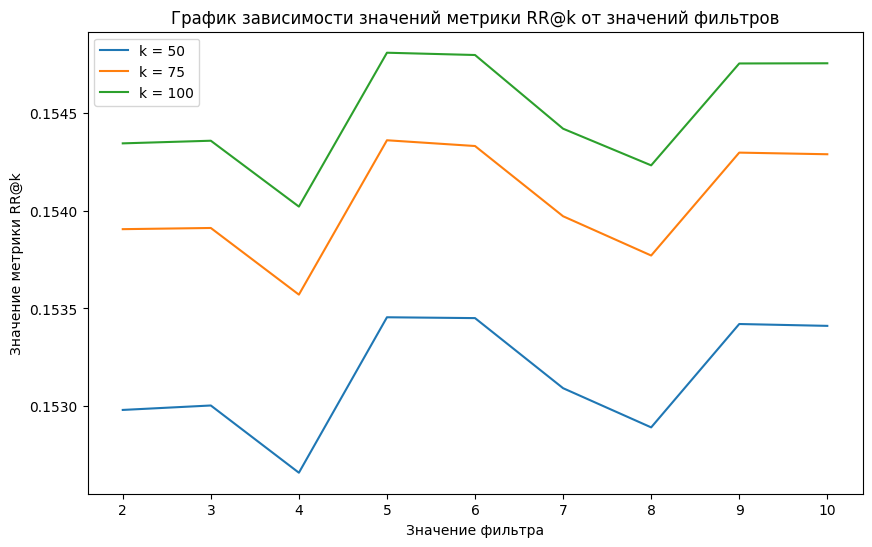

In [324]:
plt.figure(figsize = (10, 6))
plt.plot(results['min_freq'], [x['mrr'] for x in results['metrics_k50']], label = 'k = 50')
plt.plot(results['min_freq'], [x['mrr'] for x in results['metrics_k75']], label = 'k = 75')
plt.plot(results['min_freq'], [x['mrr'] for x in results['metrics_k100']], label = 'k = 100')
plt.xlabel('Значение фильтра')
plt.ylabel('Значение метрики RR@k')
plt.title('График зависимости значений метрики RR@k от значений фильтров')
plt.legend()
plt.show()

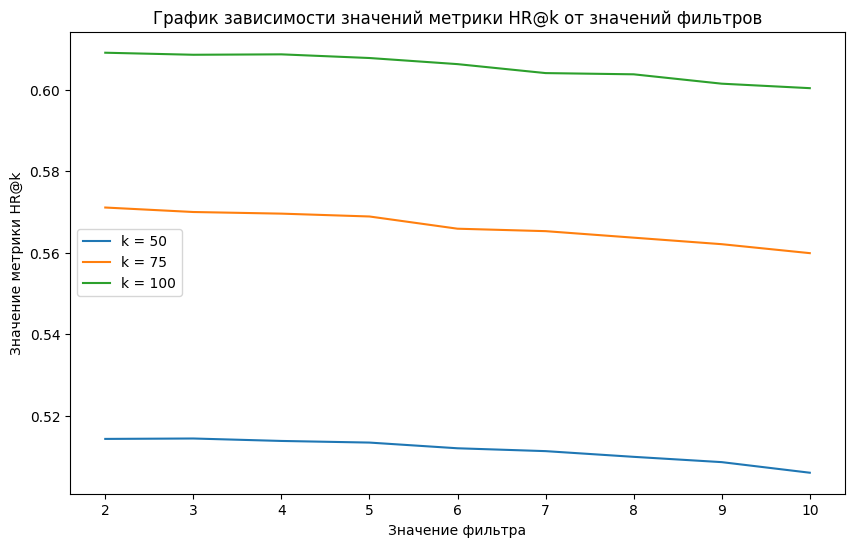

In [325]:
plt.figure(figsize = (10, 6))
plt.plot(results['min_freq'], [x['hr'] for x in results['metrics_k50']], label = 'k = 50')
plt.plot(results['min_freq'], [x['hr'] for x in results['metrics_k75']], label = 'k = 75')
plt.plot(results['min_freq'], [x['hr'] for x in results['metrics_k100']], label = 'k = 100')
plt.xlabel('Значение фильтра')
plt.ylabel('Значение метрики HR@k')
plt.title('График зависимости значений метрики HR@k от значений фильтров')
plt.legend()
plt.show()

Что вы можете сказать на основе полученных графиков? Соответствуют ли они вашим ожиданиям?

**Ответ:** При увеличениее k на всех метриках качество растёт. С усилением фильтра на число айтемов и юзеров, AP@k и HR@k падают, как и говорилось про EASE в лекции №2, однако RR@k ведёт себя скачкообразно с очень маленькой амлитудой, но в целом даже немного выросло, что было неожиданно.

**Задание №10. Интерпретируемые рекомендации**

Используйте выученную матрицу весов для item2item рекомендаций. Приведите 10 примеров топ-5 рекомендаций от EASE к сэмплируемым айтемам. Используйте названия фильмов вместо id при выводе рекомендаций. 

In [334]:
items_df = pd.read_csv('items.csv').iloc[:-1]
items_df.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео..."
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю..."
4,16268,film,Все решает мгновение,NaN,1978.0,"драмы, спорт, советские, мелодрамы",СССР,NaN,12.0,Ленфильм,Виктор Садовский,"Александр Абдулов, Александр Демьяненко, Алекс...",Расчетливая чаровница из советского кинохита «...,"Все, решает, мгновение, 1978, СССР, сильные, ж..."


In [335]:
filtered_train = filter_dataframe(train_df, min_freq = 5)
filtered_train, user2id, item2id, id2user, id2item = df_encode(filtered_train)
    
matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape = (len(user2id), len(item2id)),
)

w = fit_ease(matrix)

In [388]:
np.random.seed(42)

w_array = w.A
sample_indices = np.random.choice(range(n_items), size = 10, replace = False)

for i, idx in enumerate(sample_indices, 1):
    if idx not in id2item:
        continue
        
    original_id = id2item[idx]
    movie_title = items_df[items_df['item_id'] == original_id].iloc[0]['title']
    
    weights = w_array[idx, :].copy()
    weights[idx] = -np.inf
    
    top_indices = np.argsort(-weights)[:5]
    
    print(f"{i}) {movie_title}")
    
    for j, rec_idx in enumerate(top_indices, 1):
        if rec_idx in id2item:
            rec_id = id2item[rec_idx]
            rec_title = items_df[items_df['item_id'] == rec_id].iloc[0]['title']
            rec_weight = weights[rec_idx]
            print(f"   {j}. {rec_title} ({rec_weight:.4f})")

1) Авантюры в Барселоне
   1. Отель Д`амур (0.0038)
   2. Секстинг в Майами (0.0038)
   3. Cекс зарядка (0.0038)
   4. Секс-наркоманы (0.0029)
   5. Дневники девочки по вызову-2 (0.0028)
2) 102 далматинца
   1. 101 далматинец (0.0059)
   2. Красотка (0.0042)
   3. Холодное сердце II (0.0039)
   4. Тайна Коко (0.0029)
   5. Красавица и чудовище (0.0029)
3) Туман
   1. Радиовспышка (0.0029)
   2. Идеальный пациент (0.0024)
   3. Няня (0.0024)
   4. Призраки войны (0.0024)
   5. Нечто (0.0024)
4) Дебошир
   1. Маша (0.0157)
   2. Восемь сотен (0.0133)
   3. День города (0.0124)
   4. Проклятие ведьмы (0.0121)
   5. Перебежчик (0.0118)
5) Миёри и волшебный лес
   1. Мадагаскар (0.0026)
   2. Миньоны (0.0020)
   3. Букашки 2 (0.0019)
   4. Песнь моря (0.0019)
   5. Хрустальное небо вчерашнего дня (0.0019)
6) Хроника эпидемии
   1. Родные (0.0027)
   2. Белый снег (0.0021)
   3. Клиника счастья (0.0020)
   4. Научи меня жить (0.0019)
   5. Пассажиры (0.0019)
7) Штурм Белого дома
   1. Чёрная

Хорошие ли получились рекомендации? Почему? Есть ли хорошие примеры? Есть ли плохие? Почему бывают плохие примеры?

**Ответ:** Рекомендации выглядят не особо хорошо, так как много предложений выглядят случайными или основанными на неоднозначных признаках. Есть как хорошие примеры (102 далматинца -> 101 далматинец), так и плохие (Нерка. Рыба красная -> Зелёная книга). Вероятно, необходимо учитывать дополнительные параметры, например тематику или целевую аудиторию.